In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib as mpl
import numpy as np
from scipy.interpolate import interp1d
import re
mpl.rcParams['svg.fonttype'] = 'none'
from scipy.optimize import root_scalar
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import glob
import matplotlib.cm as cm
import seaborn as sns
from scipy.stats import gaussian_kde
from math import sqrt, pi
import pickle
from collections import defaultdict
from itertools import product
import gurobipy as gp
from gurobipy import GRB

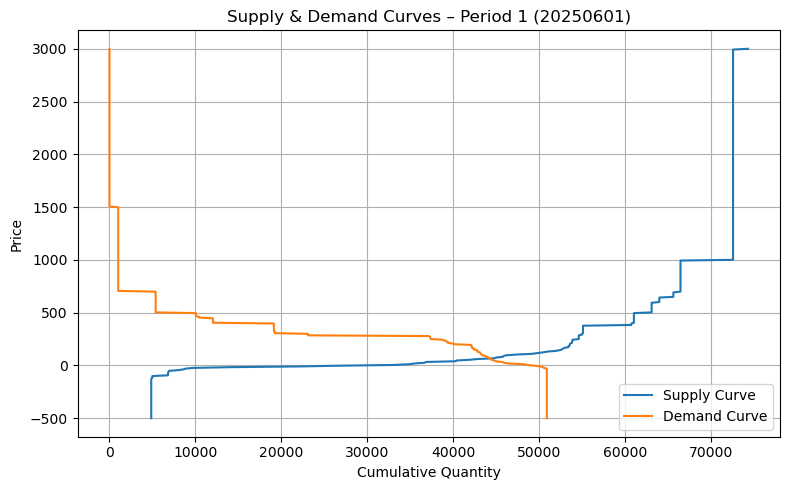

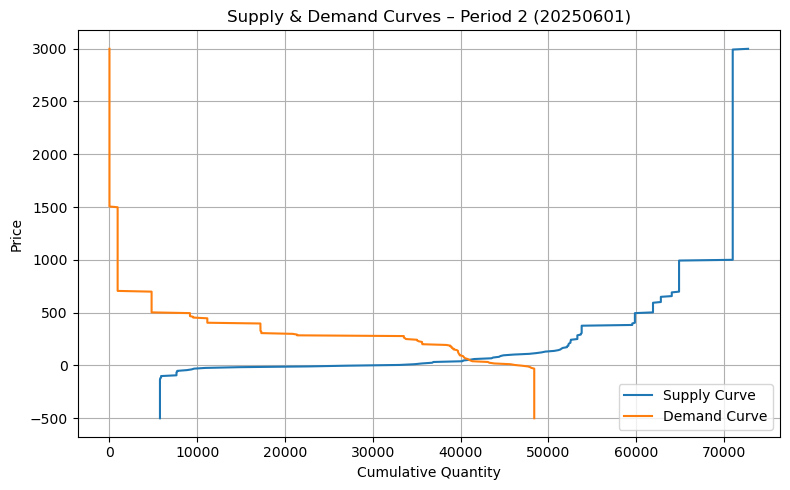

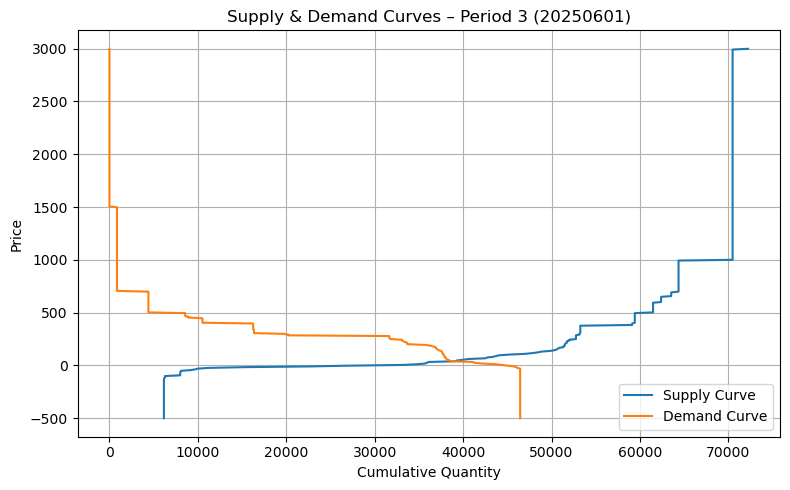

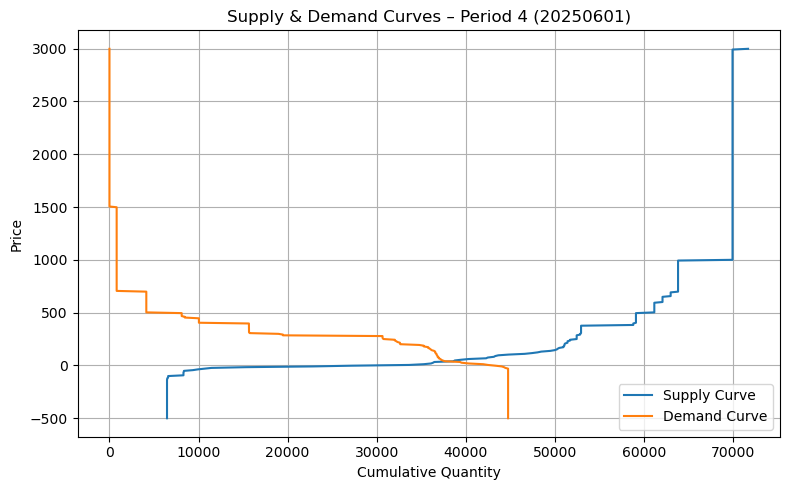

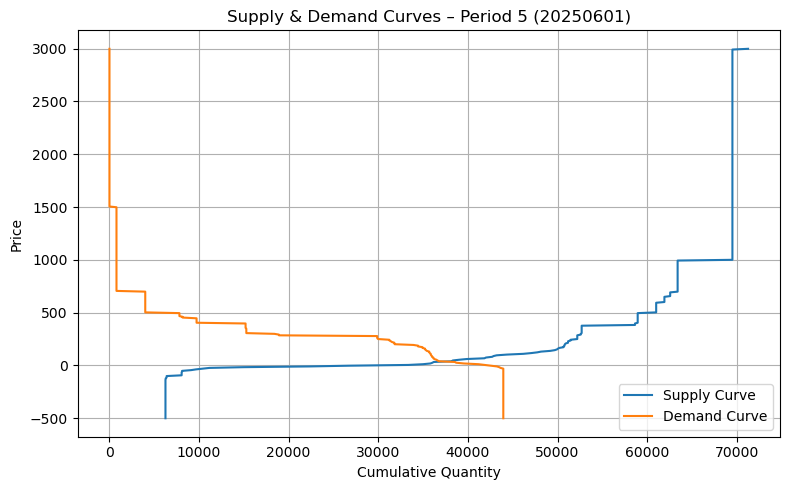

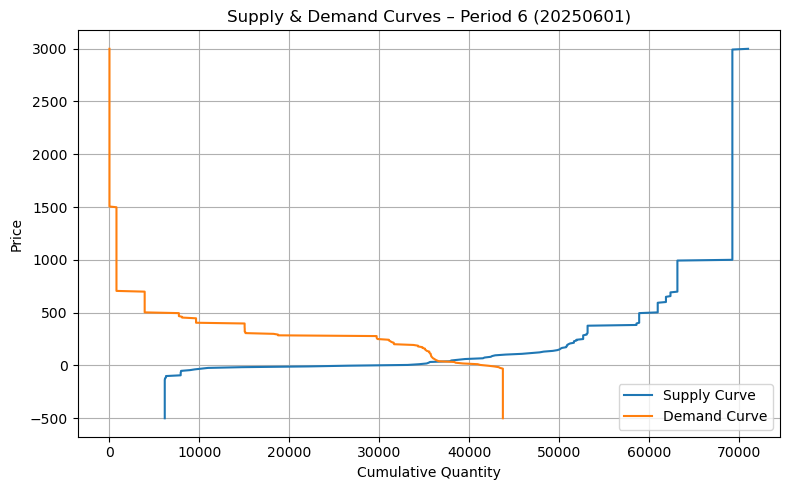

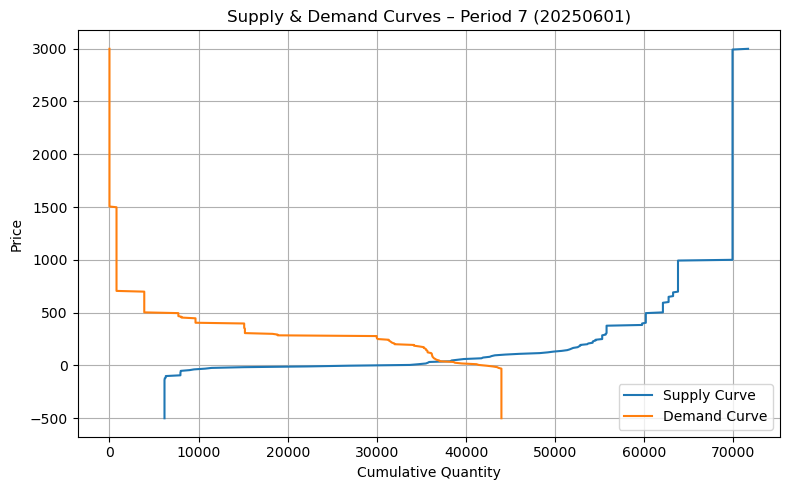

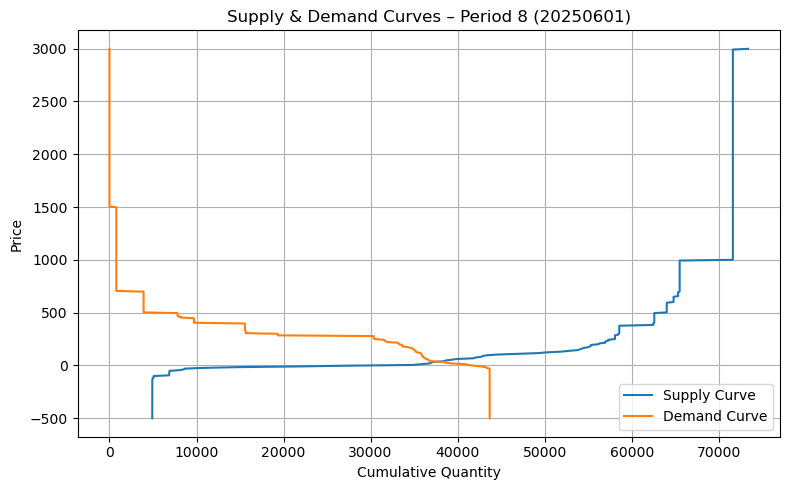

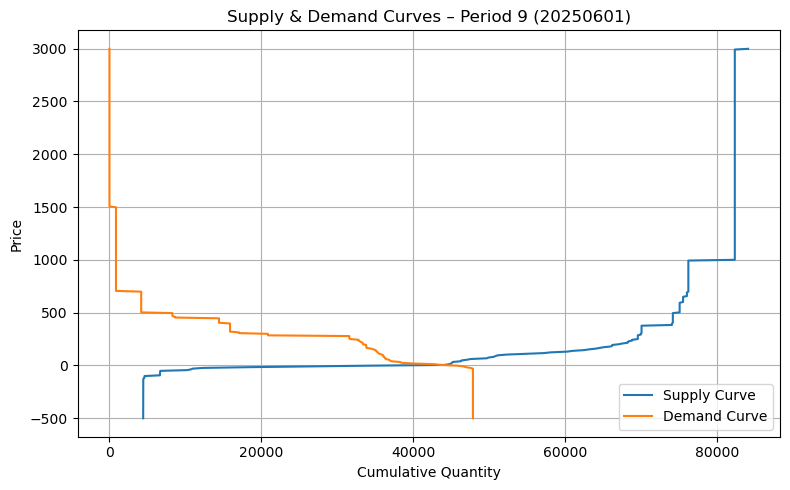

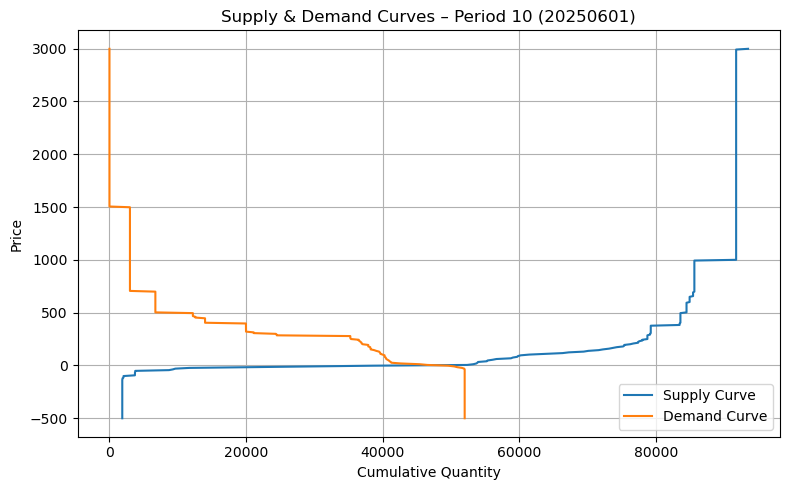

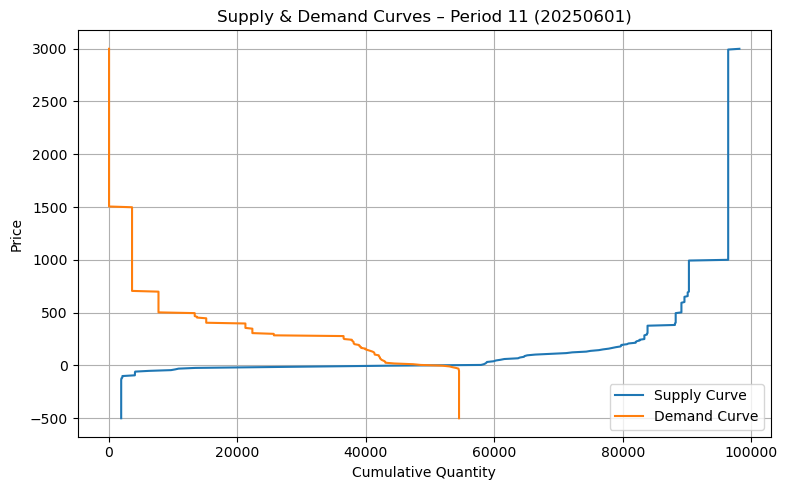

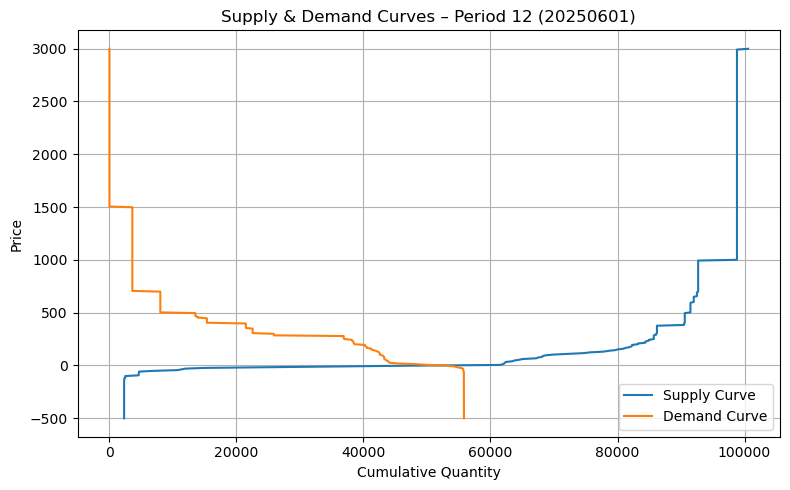

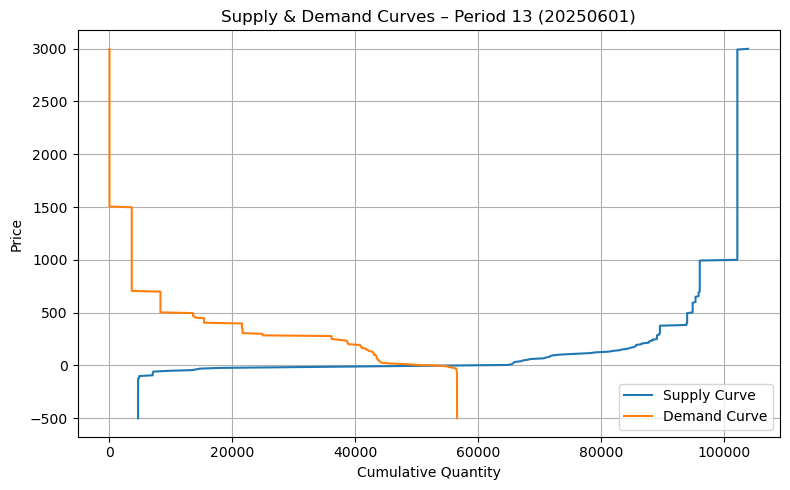

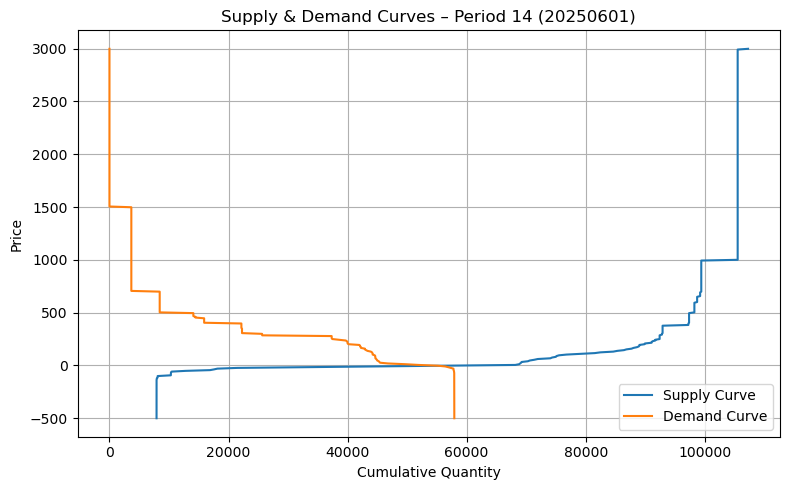

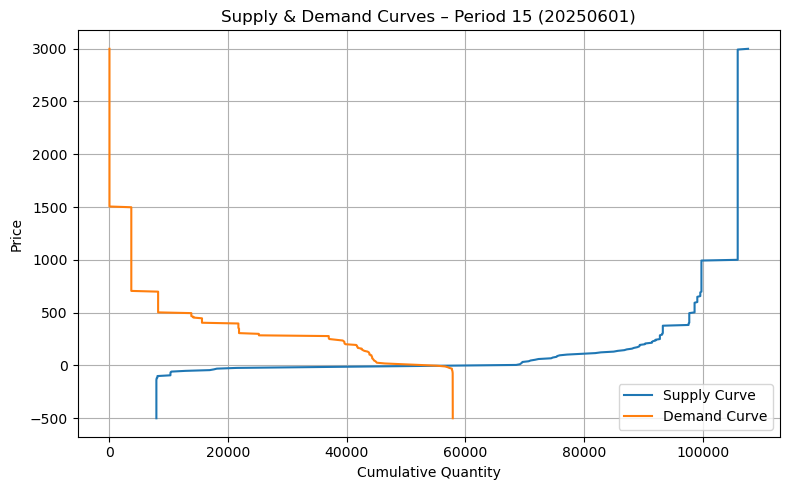

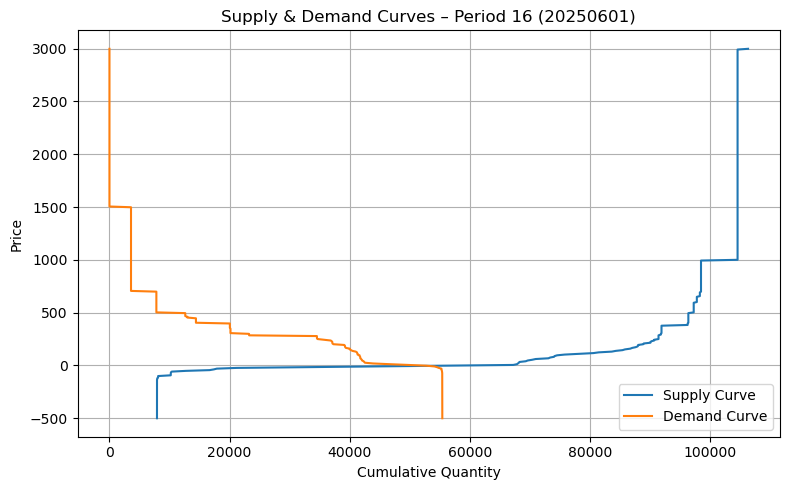

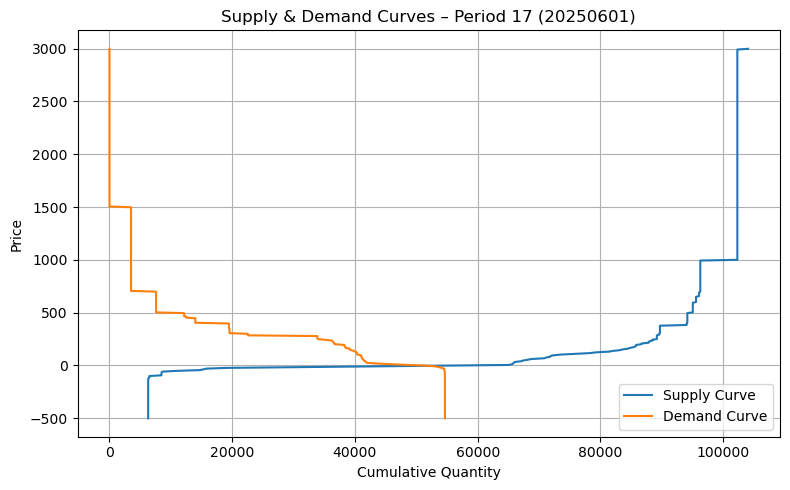

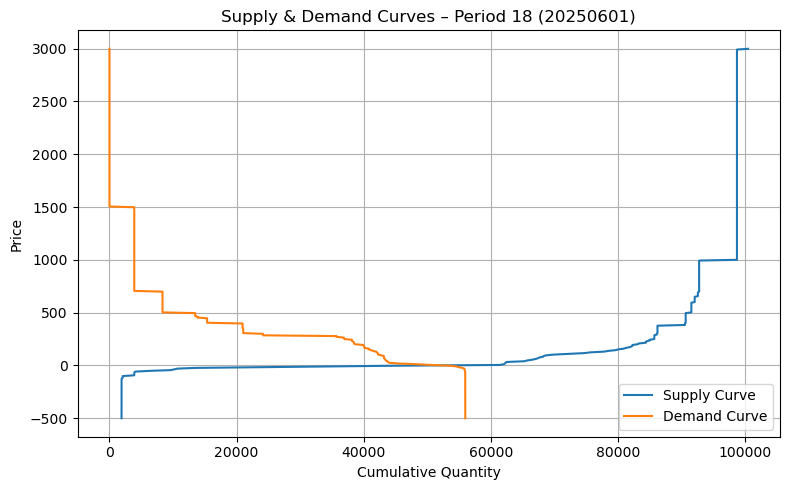

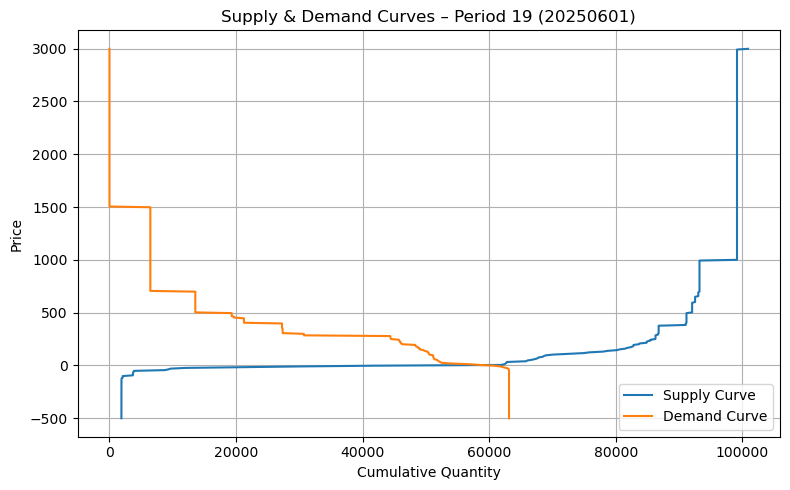

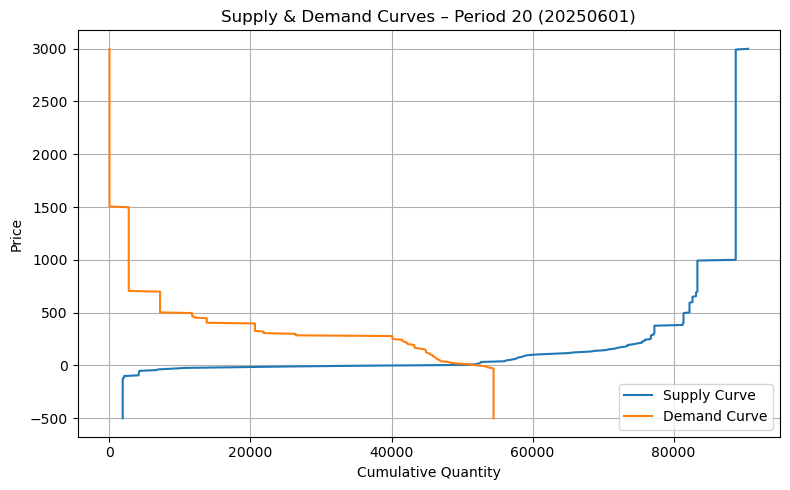

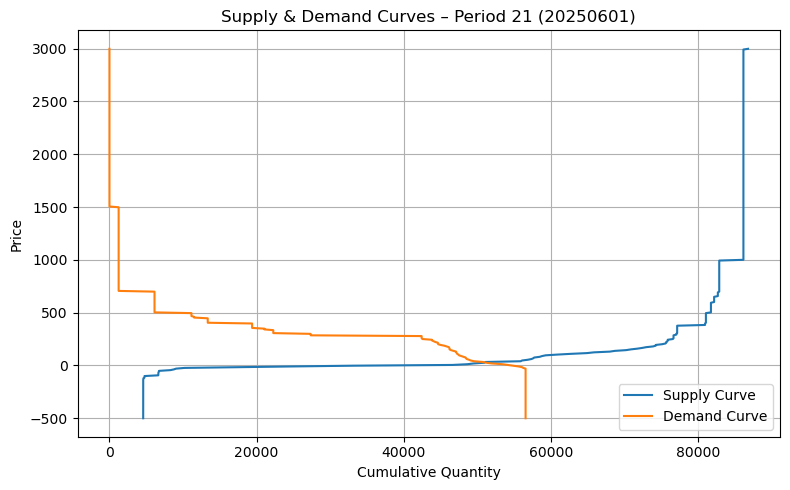

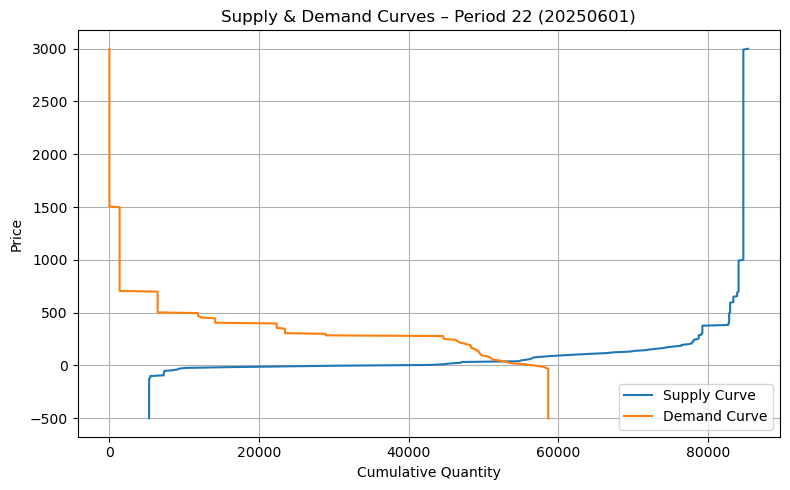

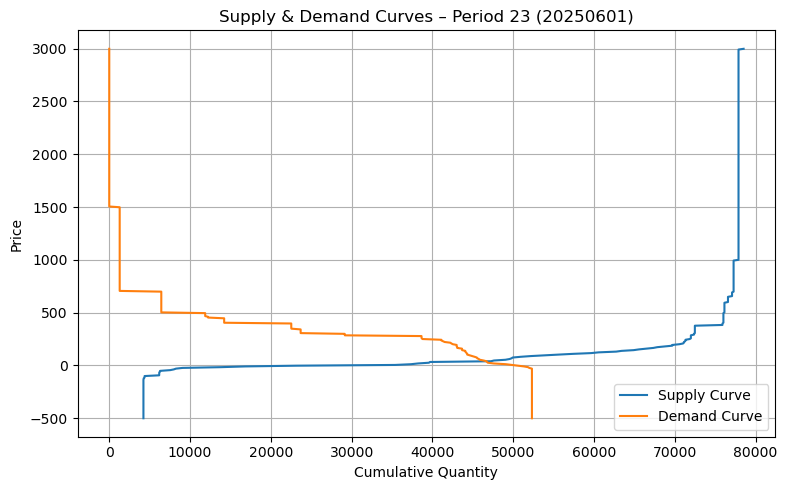

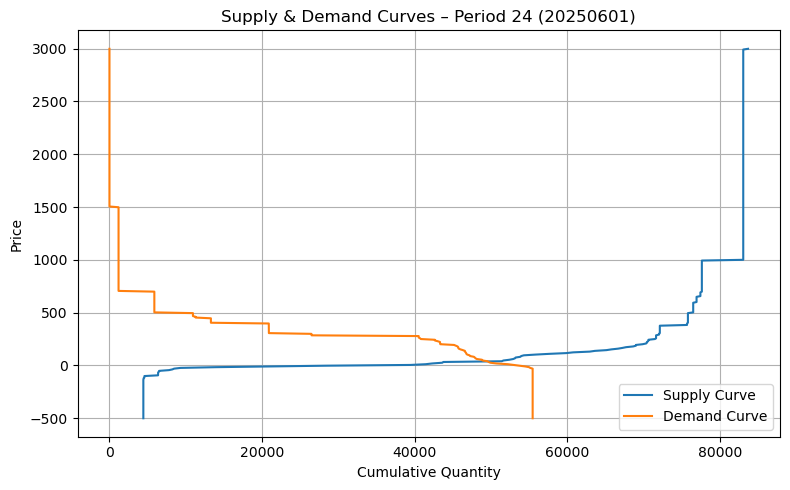

In [2]:
# --------------------------
# 대상 날짜 지정
# --------------------------
date_str = "20250601"
file_in = f"filteredcurve_{date_str}.csv"

# 파일 불러오기
try:
    df = pd.read_csv(file_in, sep=',', encoding='utf-8-sig')
except FileNotFoundError:
    print(f"파일 없음: {file_in}")
    raise

# --------------------------
# 24시간(Period 1~24) 반복
# --------------------------
for period in range(1, 25):  # 1~24
    mask = df['Time Period'] == period
    supply = df[mask & (df['GC'] == 'V')]
    demand = df[mask & (df['GC'] == 'C')]

    if supply.empty or demand.empty:
        print(f"{date_str} Period {period}: 데이터 없음, 건너뜀")
        continue

    # 공급 집계
    supply_agg = (
        supply.groupby('Price')['Amount']
              .sum()
              .reset_index()
              .sort_values('Price')
    )
    supply_agg['CumulQty'] = supply_agg['Amount'].cumsum()

    # 수요 집계
    demand_agg = (
        demand.groupby('Price')['Amount']
              .sum()
              .reset_index()
              .sort_values('Price')
    )
    demand_agg['CumulQty'] = demand_agg['Amount'][::-1].cumsum()[::-1]

    # 보간 함수
    supply_func = interp1d(
        supply_agg['Price'], supply_agg['CumulQty'],
        kind='previous', bounds_error=False,
        fill_value=(0, supply_agg['CumulQty'].iloc[-1])
    )
    demand_func = interp1d(
        demand_agg['Price'], demand_agg['CumulQty'],
        kind='previous', bounds_error=False,
        fill_value=(demand_agg['CumulQty'].iloc[0], 0)
    )

    # 가격 그리드
    pmin = min(supply_agg['Price'].min(), demand_agg['Price'].min())
    pmax = max(supply_agg['Price'].max(), demand_agg['Price'].max())
    price_grid = np.linspace(pmin, pmax, 500)
    supply_vals = supply_func(price_grid)
    demand_vals = demand_func(price_grid)

    # 플롯
    plt.figure(figsize=(8,5))
    plt.plot(supply_vals, price_grid, label='Supply Curve')
    plt.plot(demand_vals, price_grid, label='Demand Curve')
    plt.xlabel('Cumulative Quantity')
    plt.ylabel('Price')
    plt.title(f'Supply & Demand Curves – Period {period} ({date_str})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [3]:
# --- RDC 계산 함수 ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0,p1 = price_grid[i], price_grid[i+1]
            r0,r1 = resid[i], resid[i+1]
            if r1!=r0:
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q,p_star))
    return rdc

# --- 공통 설정 ---
date_str      = "20250601"
scenario_dir  = f"scenarios_{date_str}"
scenario_files = sorted([f for f in os.listdir(scenario_dir) if f.endswith(".csv")])

wf_offer_grid = np.arange(0, 2000, 10)
B             = 500   # stepwise block 수
colors        = plt.cm.tab10(np.linspace(0,1,len(scenario_files)))

# stepwise 파라미터 저장용 dict
qini            = {}
qmax            = {}
lambda_da_block = {}
orig_cp         = {}

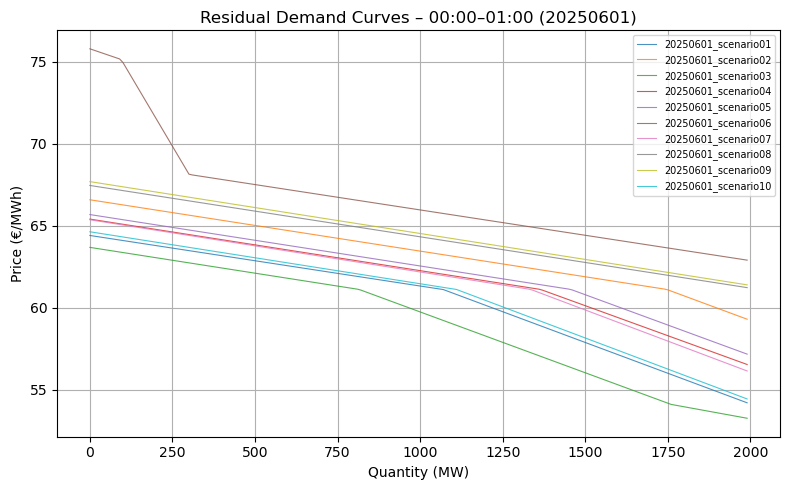

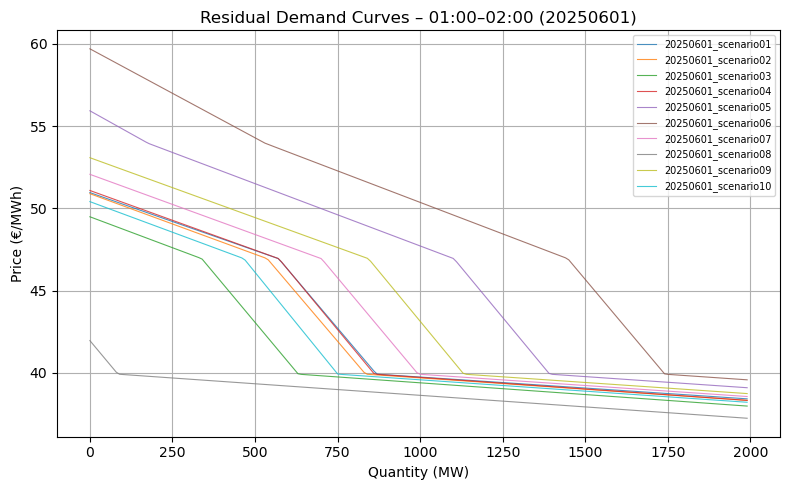

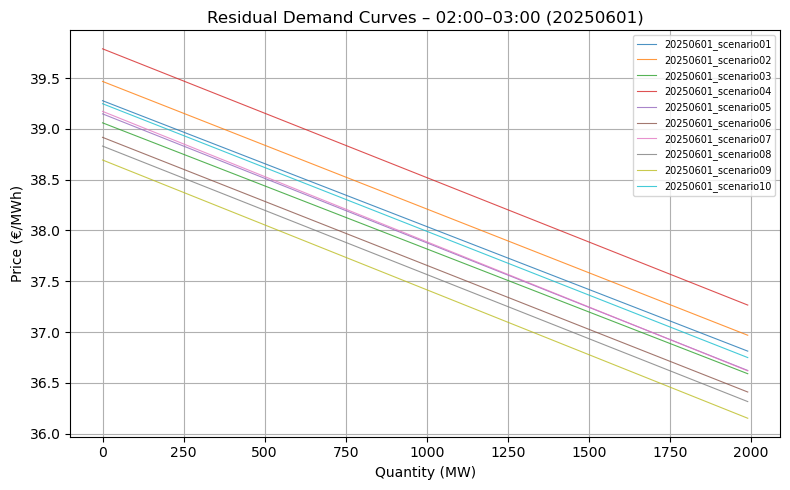

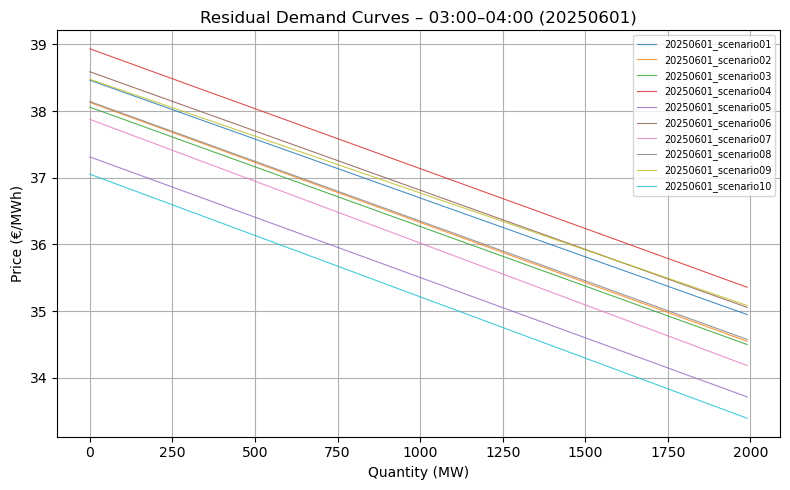

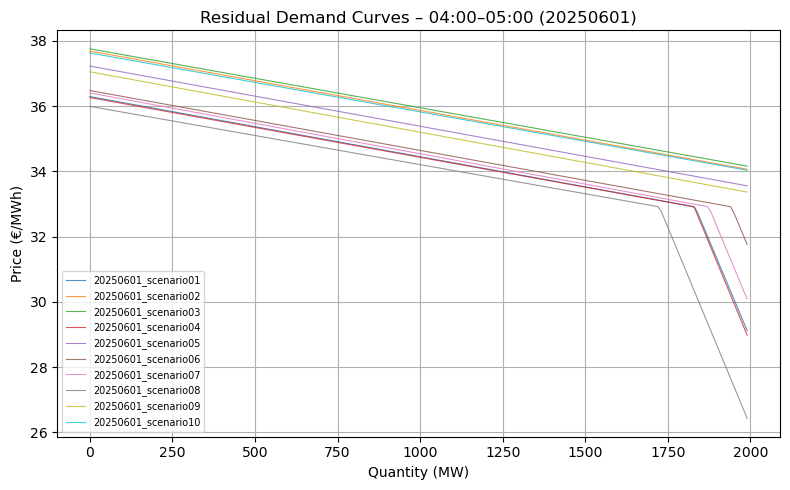

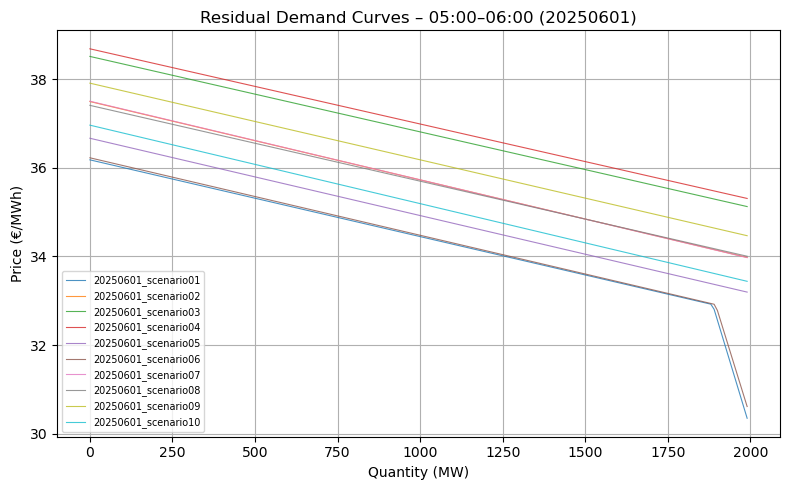

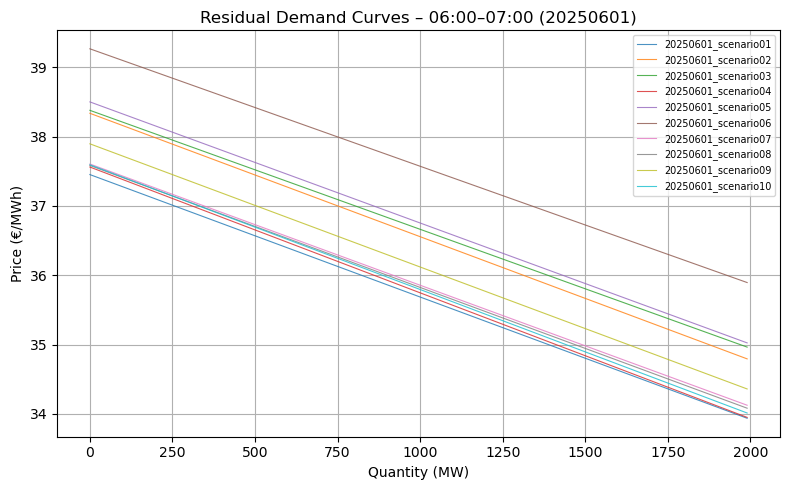

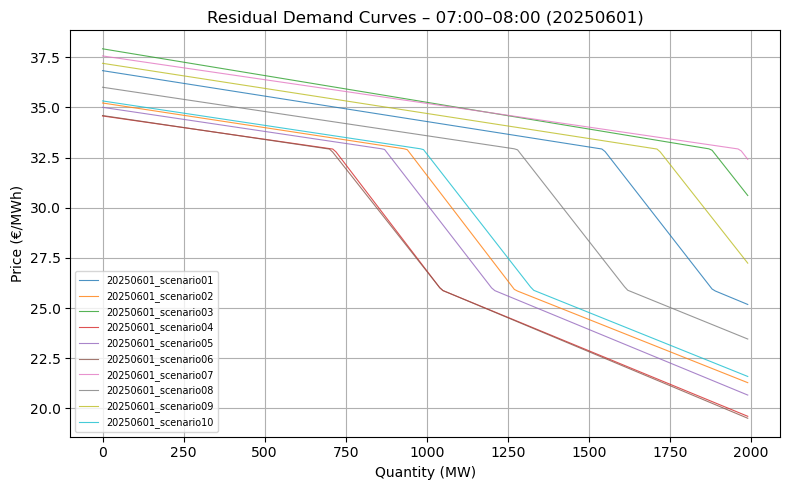

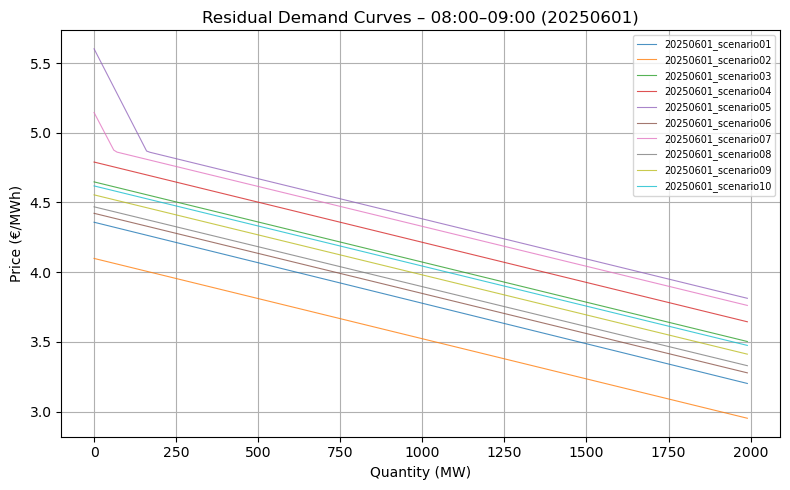

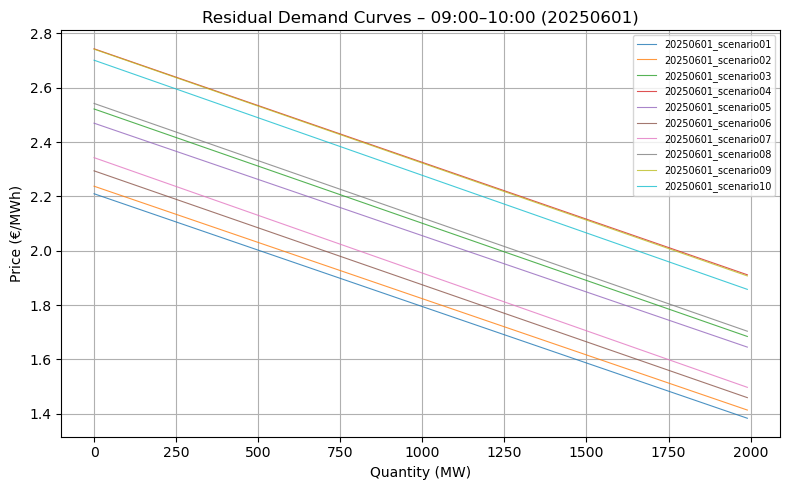

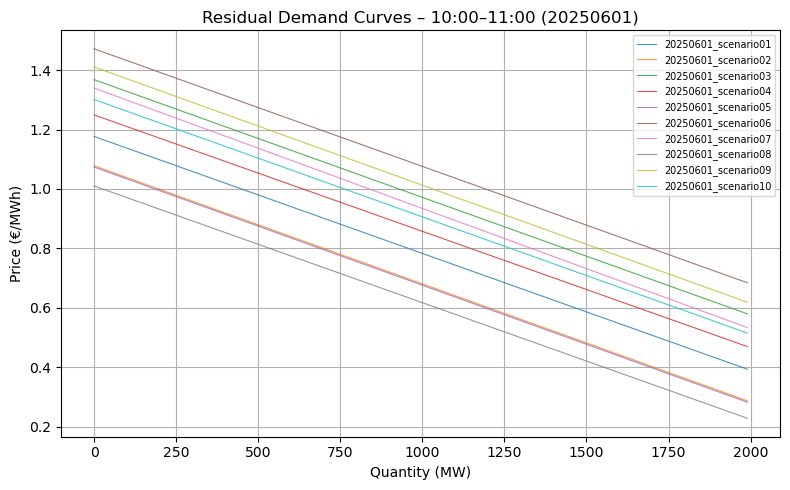

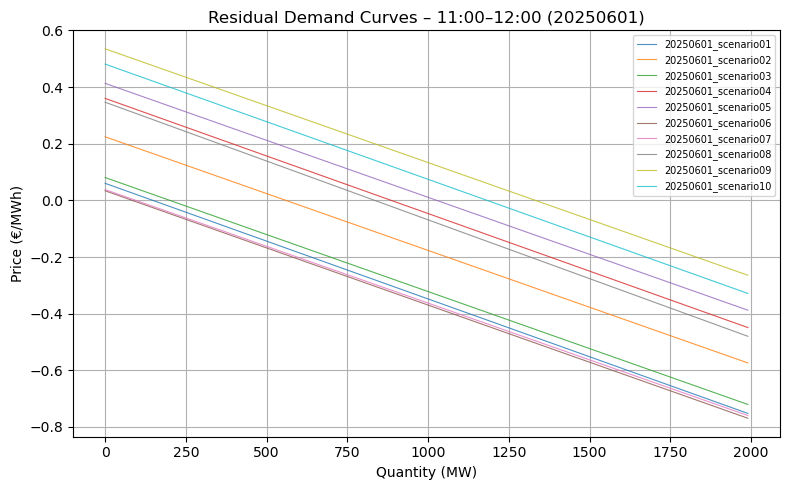

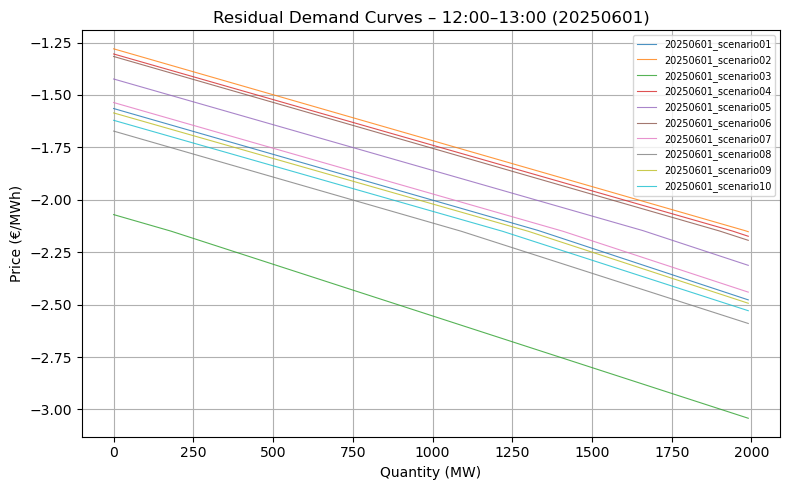

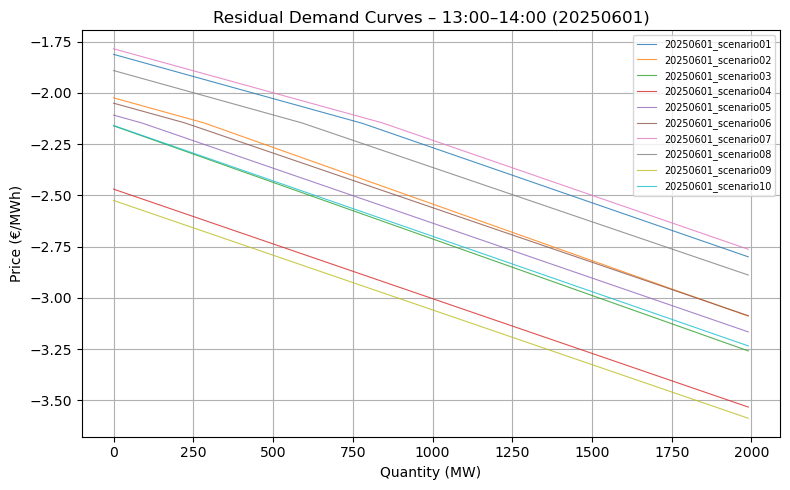

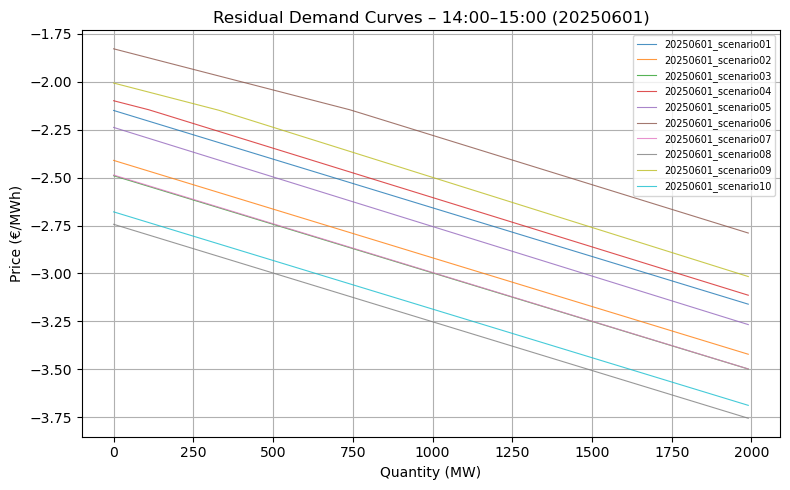

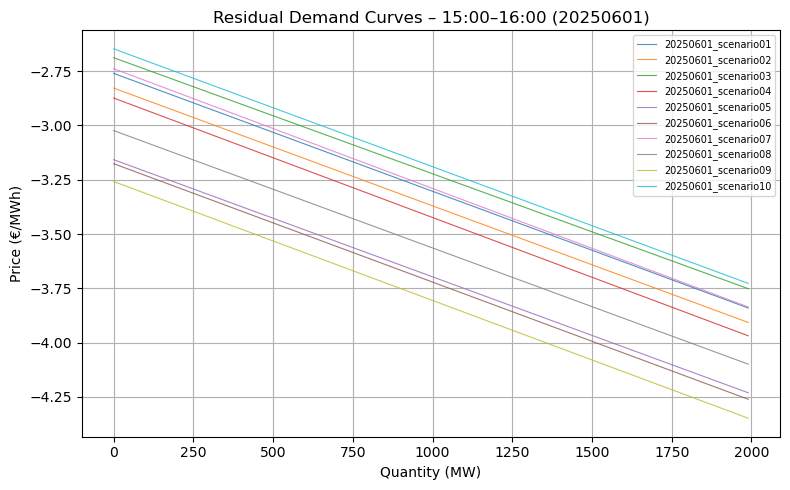

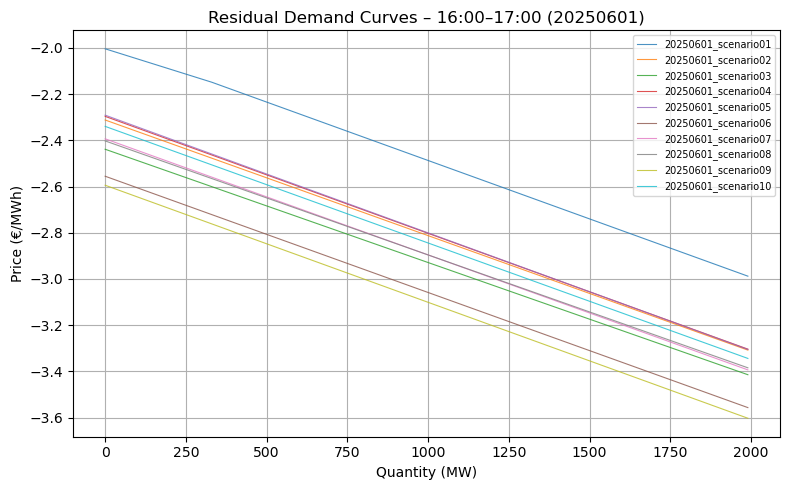

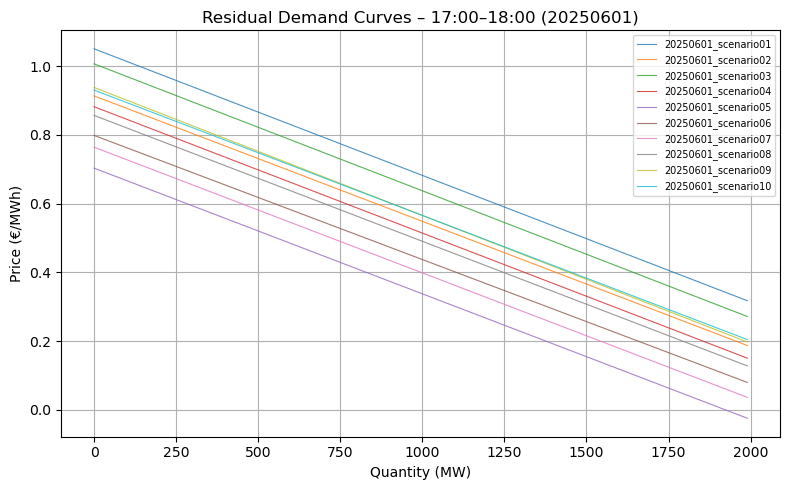

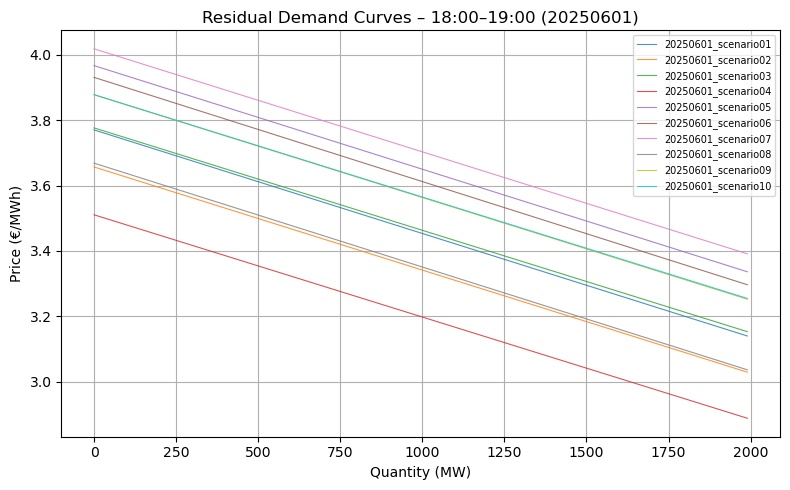

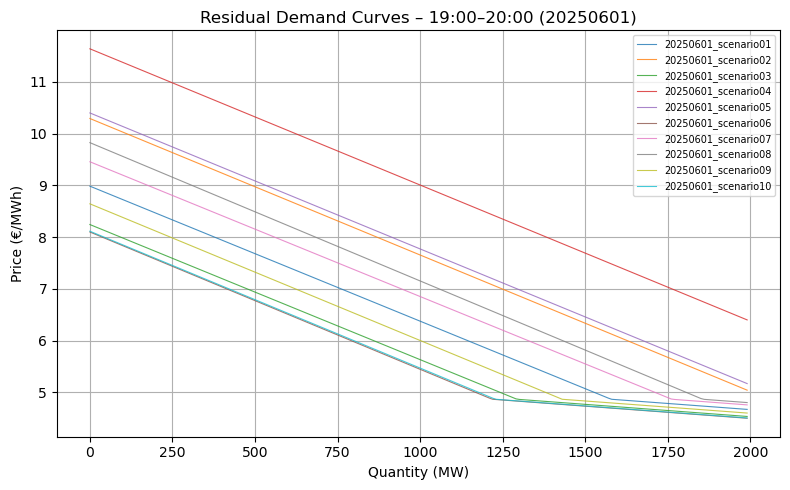

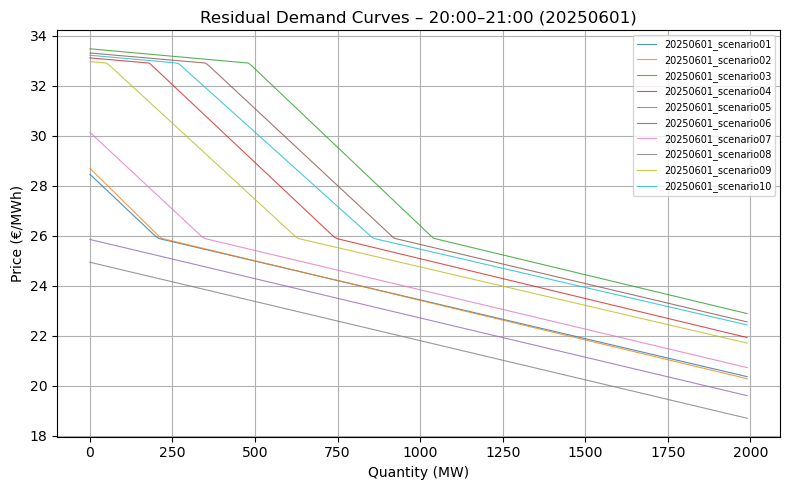

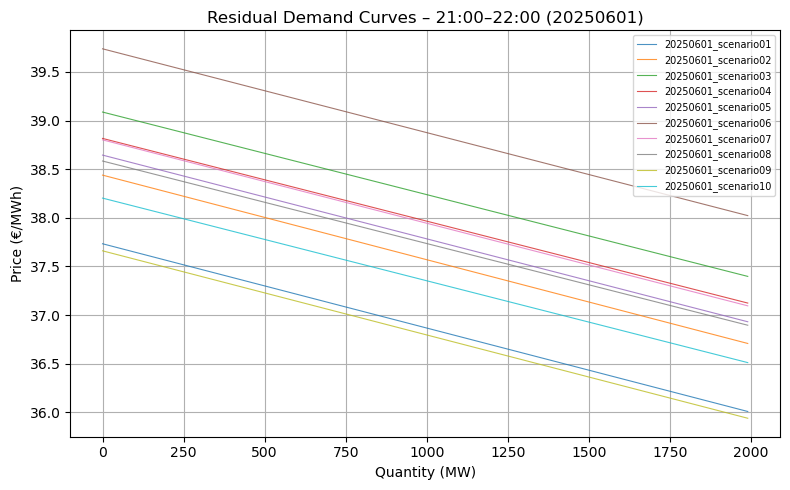

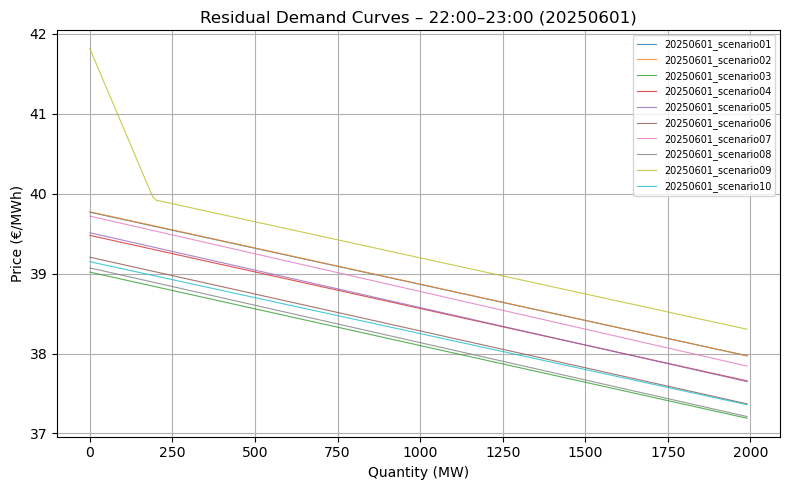

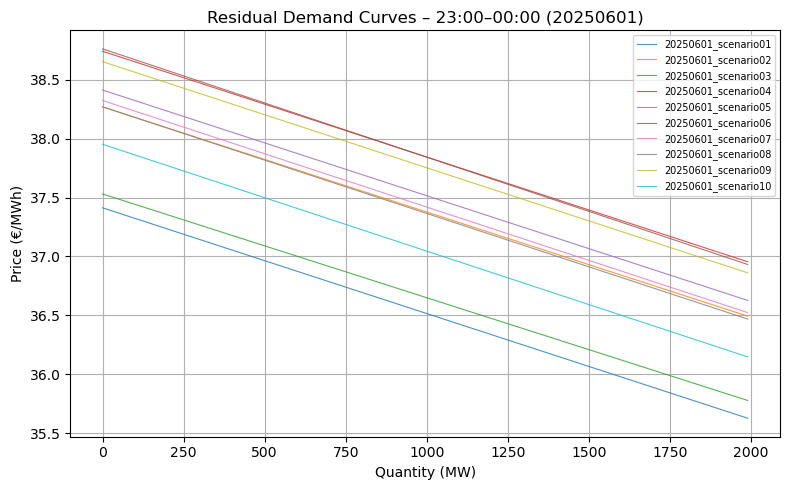

In [4]:
colors        = plt.cm.tab10(np.linspace(0,1,len(scenario_files)))

# --- 시간대별 Figure 하나씩 ---
for period in range(1,25):

    plt.figure(figsize=(8,5))

    for file, color in zip(scenario_files, colors):
        scen_name = os.path.splitext(file)[0]
        fn        = os.path.join(scenario_dir, file)
        df        = pd.read_csv(fn, encoding='utf-8-sig')

        sub = df[df['Time Period']==period]
        sup = sub[sub['GC']=='V']
        dem = sub[sub['GC']=='C']
        if sup.empty or dem.empty:
            continue

        # 공급/수요 집계
        s_agg = sup.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        s_agg['Cumul'] = s_agg['Amount'].cumsum()

        d_agg = dem.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

        # 보간
        s_f = interp1d(s_agg['Price'], s_agg['Cumul'],
                       kind='previous', bounds_error=False,
                       fill_value=(0, s_agg['Cumul'].iat[-1]))
        d_f = interp1d(d_agg['Price'], d_agg['Cumul'],
                       kind='previous', bounds_error=False,
                       fill_value=(d_agg['Cumul'].iat[0], 0))

        pg = np.linspace(min(s_agg['Price'].min(), d_agg['Price'].min()),
                         max(s_agg['Price'].max(), d_agg['Price'].max()), 500)
        sv = s_f(pg); dv = d_f(pg)

        # RDC 계산
        rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
        if not rdc_pts:
            continue
        qv, pv = zip(*rdc_pts)

        # stepwise 블록 경계 만들기
        q_breaks = np.linspace(min(qv), max(qv), B+1)

        for b in range(B):
            q_low, q_high = q_breaks[b], q_breaks[b+1]
            mask = (np.array(qv) >= q_low) & (np.array(qv) < q_high)
            if not mask.any():
                continue
            # 블록 내 대표값 (qini, qmax, lam_da)
            qini[(scen_name, period, b)] = q_low
            qmax[(scen_name, period, b)] = q_high - q_low
            lambda_da_block[(scen_name, period, b)] = np.mean(np.array(pv)[mask])


        # --- Plot ---
        plt.plot(qv, pv, '-', color=color, linewidth=0.8, alpha=0.8, label=scen_name)

    # 시간대별 제목
    hh1 = f"{period-1:02d}:00"; hh2 = f"{period%24:02d}:00"
    plt.title(f"Residual Demand Curves – {hh1}–{hh2} ({date_str})")

    plt.xlabel("Quantity (MW)")
    plt.ylabel("Price (€/MWh)")
    plt.grid(True)
    plt.legend(fontsize=7)
    plt.tight_layout()
    plt.show()


              scenario  t   b   qini  qmax     lam_da
0  20250601_scenario01  1   0   0.00  3.98  64.413927
1  20250601_scenario01  1   2   7.96  3.98  64.383133
2  20250601_scenario01  1   5  19.90  3.98  64.352339
3  20250601_scenario01  1   7  27.86  3.98  64.321544
4  20250601_scenario01  1  10  39.80  3.98  64.290750


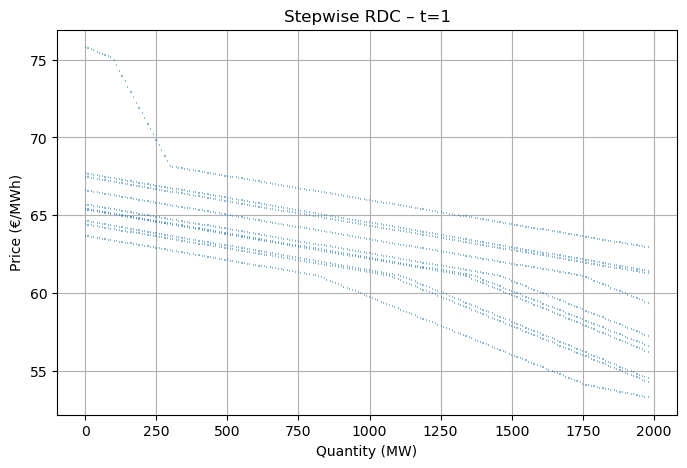

In [5]:
# 1) 저장된 CSV 불러오기
df = pd.read_csv("rdc_scenarios.csv", encoding="utf-8-sig")

print(df.head())   # 데이터 확인 (앞 5줄)

# 2) 특정 시간(t)에서 모든 시나리오 곡선 그리기
t_to_plot = 1   # 예: 2시(hour 2)

plt.figure(figsize=(8,5))

for scen in df["scenario"].unique():
    sub = df[(df["scenario"]==scen) & (df["t"]==t_to_plot)]
    if sub.empty:
        continue
    
    # qini ~ qini+qmax 까지 구간별 step plot
    q_starts = sub["qini"].values
    q_ends   = sub["qini"].values + sub["qmax"].values
    prices   = sub["lam_da"].values
    
    for qs, qe, p in zip(q_starts, q_ends, prices):
        plt.hlines(y=p, xmin=qs, xmax=qe, color="C0", alpha=0.5)
    
plt.xlabel("Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title(f"Stepwise RDC – t={t_to_plot}")
plt.grid(True)
plt.show()

In [8]:
I = list(range(1))                                     # 풍력 설비 0번만
T = list(range(1, 25))                                # 시간 1~24
J = [1,2,3,4]
S = list(range(10))                     # 시나리오 0~7


In [9]:
# 15분 분할
#7월 20일 기준
rt_price_15min = [
    75.78, 75.54, 72.72, 42.23, 75.30, 75.30, 61.91, 35.25, 75.30, 48.33,
    39.81, 23.08, 65.80, 49.92, 33.81, 18.07, 45.68, 35.81, 26.04, 30.98,
    32.11, 36.47, 34.14, 29.49, 27.58, 34.34, 21.44, 33.44, 26.00,  3.30,
    -1.99, -8.99, 28.79,  0.49, -5.51, -6.31,  3.52,  0.65, -1.01, -5.90,
    -0.97, -3.00, -3.00,  0.00,  0.01,  4.31,  0.00,  0.00,  0.99,  0.99,
     0.14,  0.00,  0.65,  0.65,  0.65,  0.00,  0.99,  0.00,  0.00,  0.00,
    -0.65, -0.65, -0.50, -0.65,  0.00,  0.00,  0.00, -0.01, -0.61,  0.00,
     0.00,  0.00,  0.00,  0.00,  0.00,  0.00, -9.70, -0.97, 20.33, 79.89,
    -8.99,  8.81, 49.88, 83.87, 36.84, 66.60, 72.19, 75.54, 82.80, 82.80,
    85.21, 82.01, 86.16, 78.72, 72.27, 53.31
]
rt_price_15min = 0.5 * np.array(rt_price_15min)  # 15분 단위 RT 가격
# 1) 15분 가격을 (24시간 × 4구간) 배열로 재형성
rt15_arr = np.array(rt_price_15min).reshape(24, 4)

# (t,j) → price 사전 생성
#  t=1..24,  j=1..4
lambda_rt = {
    (t, j): float(rt15_arr[t-1, j-1])
    for t in T for j in J
}
sigma_eta = 0.1  # 실시간 가격 변동성 (5%)
# λ_rt_act[(t,j,s)] : 시나리오 s의 시간 t, 구간 j 실시간 가격
lambda_rt_act = {
    (t, j, s): rt15_arr[t-1, j-1] * (1 + sigma_eta * np.random.randn())
    for t in T for j in J for s in S
}

In [10]:
sigma_frac = 0.05   # 5% 변동성
mu_frac    = 0.95   # 평균 95% 정격출력
Cw = 1000

np.random.seed(0)
pwf = {
    (i,t,s): max(0, np.random.normal(Cw*mu_frac, Cw*sigma_frac))
    for i in I for t in T for s in S
}

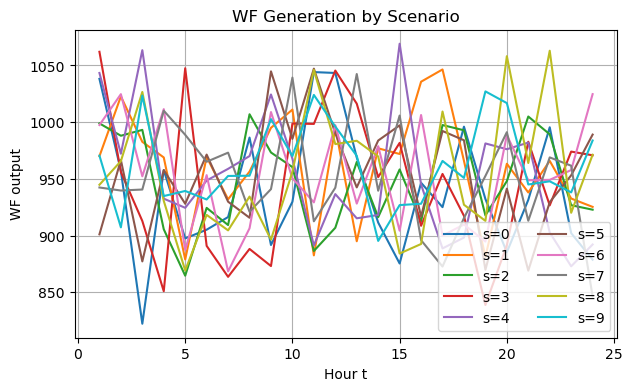

[CHECK] RT act min/max: -5.58 / 48.57,  negatives: 180개
[CHECK] WF  min/max/mean: 822.4 / 1069.2 / 952.4


In [11]:
i0 = I[0]
fig4 = plt.figure(figsize=(7,4))
for s in S:
    wf_t = [pwf[(i0,t,s)] for t in T]
    plt.plot(T, wf_t, label=f"s={s}")
plt.title('WF Generation by Scenario')
plt.xlabel('Hour t')
plt.ylabel('WF output')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

# --- 5) 빠른 통계/이상치 점검 ---
rt_all = np.array([lambda_rt_act[(t,j,s)] for t in T for j in J for s in S])
wf_all = np.array([pwf[(i0,t,s)] for t in T for s in S])

neg_rt = np.sum(rt_all < 0)
print(f"[CHECK] RT act min/max: {rt_all.min():.2f} / {rt_all.max():.2f},  negatives: {neg_rt}개")
print(f"[CHECK] WF  min/max/mean: {wf_all.min():.1f} / {wf_all.max():.1f} / {wf_all.mean():.1f}")


In [15]:

# 1) CSV 불러오기
df = pd.read_csv("rdc_scenarios.csv", encoding="utf-8-sig")

# ────────────────────────────────
# 2) 날짜 / 시나리오 / 시간 정의
date_range = [f"202507{d:02d}" for d in range(20, 30)]  # 20,21,…,29
S = list(range(len(date_range)))                        # 시나리오 0~9
T = list(range(1, 25))                                  # 시간 1~24
I = [0]                                                 # 풍력 설비 0번만
J = [1,2,3,4]                                           # 15분 분할
Δt = 0.25

# 시나리오 확률 (균등)
rho = {s: 1/len(S) for s in S}

# ────────────────────────────────
# 3) 시나리오 맵 생성
qini_scen       = {}
qmax_scen       = {}
lambda_da_scen  = {}

# CSV에는 "scenario", "t", "qini", "qmax", "lam_da"가 있다고 가정
# for _, row in df.iterrows():
#     s = int(row["scenario"])
#     t = int(row["t"])
#     qini_val = float(row["qini"])
#     qmax_val = float(row["qmax"])
#     lam_val  = float(row["lam_da"])
    
#     # block index b는 enumerate로 부여 (같은 t 안에서 0,1,2,...)
#     # CSV에 block 정보가 없다고 가정 → qini 기준으로 sort 후 생성
#     # 우선 t,s별 그룹핑
#     # 나중에 valid_blocks 만들 때 Δ>0인 b만 남길 것임
    
#     # 임시로 key를 (s,t,qini)로 저장해두고 나중에 b index 매핑
#     qini_scen[(s,t,qini_val)] = qini_val
#     qmax_scen[(s,t,qini_val)] = qmax_val
#     lambda_da_scen[(s,t,qini_val)] = lam_val
for _, row in df.iterrows():
    s = str(row["scenario"])   # 문자열 그대로
    t = int(row["t"])
    qini_val = float(row["qini"])
    qmax_val = float(row["qmax"])
    lam_val  = float(row["lam_da"])

    qini_scen[(s,t,qini_val)]      = qini_val
    qmax_scen[(s,t,qini_val)]      = qmax_val
    lambda_da_scen[(s,t,qini_val)] = lam_val

# ────────────────────────────────
# 4) block index 부여
qini_scen_final       = {}
qmax_scen_final       = {}
lambda_da_scen_final  = {}

valid_blocks = {t: [] for t in T}

for (s,t), sub in df.groupby(["scenario","t"]):
    # qini 기준 정렬
    sub_sorted = sub.sort_values("qini").reset_index(drop=True)
    for b, r in sub_sorted.iterrows():
        qini_scen_final[(t,b,s)] = float(r["qini"])
        qmax_scen_final[(t,b,s)] = float(r["qmax"])
        lambda_da_scen_final[(t,b,s)] = float(r["lam_da"])
        if r["qmax"] > 0:
            valid_blocks[t].append(b)

# 중복 제거 및 정렬
valid_blocks = {t: sorted(set(bs)) for t, bs in valid_blocks.items()}

# ────────────────────────────────
# 최종 결과 확인
print("rho:", rho)
print("예시 qini_scen_final keys:", list(qini_scen_final.keys())[:10])
print("예시 valid_blocks:", {t: valid_blocks[t] for t in range(1,4)})


rho: {0: 0.1, 1: 0.1, 2: 0.1, 3: 0.1, 4: 0.1, 5: 0.1, 6: 0.1, 7: 0.1, 8: 0.1, 9: 0.1}
예시 qini_scen_final keys: [(1, 0, '20250601_scenario01'), (1, 1, '20250601_scenario01'), (1, 2, '20250601_scenario01'), (1, 3, '20250601_scenario01'), (1, 4, '20250601_scenario01'), (1, 5, '20250601_scenario01'), (1, 6, '20250601_scenario01'), (1, 7, '20250601_scenario01'), (1, 8, '20250601_scenario01'), (1, 9, '20250601_scenario01')]
예시 valid_blocks: {1: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 1

In [19]:
# 이건 10개 그냥 만드는거
group_size = 10
scenario_groups = [S[i:i+group_size] for i in range(0, len(S), group_size)]

combined_scenarios = []

for group in scenario_groups:
    # RDC 묶기: (qini, qmax, lambda_da)
    rdc_sub = {
        (t,b,s): (
            qini_scen[(t,b,s)],
            qmax_scen[(t,b,s)],
            lambda_da_scen[(t,b,s)]
        )
        for (t,b,s) in qini_scen if s in group
    }
    
    # Generation
    pwf_sub = {
        (i,t,s): pwf[(i,t,s)]
        for (i,t,s) in pwf if s in group
    }
    
    # RT Price
    rt_sub = {
        (t,j,s): lambda_rt_act[(t,j,s)]
        for (t,j,s) in lambda_rt_act if s in group
    }
    
    combined_scenarios.append((rdc_sub, pwf_sub, rt_sub))

# ────────────────────────────────
# 결과 확인
print(f"총 {len(combined_scenarios)} 개의 묶음 생성")
print("첫 번째 묶음 예시:")
rdc_sub, pwf_sub, rt_sub = combined_scenarios[0]
print("RDC sample:", list(rdc_sub.items())[:3])
print("PWF sample:", list(pwf_sub.items())[:3])
print("RT sample :", list(rt_sub.items())[:3])


총 1 개의 묶음 생성
첫 번째 묶음 예시:
RDC sample: [(('20250601_scenario01', 1, 0.0), (0.0, 3.98, 64.41392693527469)), (('20250601_scenario01', 2, 0.0), (0.0, 3.98, 50.95478335582048)), (('20250601_scenario01', 3, 0.0), (0.0, 3.98, 39.27731488584383))]
PWF sample: [((0, 1, 0), 1038.2026172983833), ((0, 1, 1), 970.0078604183611), ((0, 1, 2), 998.936899205287)]
RT sample : [((1, 1, 0), 41.58812482549511), ((1, 1, 1), 42.19055905440443), ((1, 1, 2), 43.522550570151445)]


In [ ]:
'''시나리오 1: RDC 시나리오 생성'''
# 1) 날짜 및 시나리오 정의
date_range = [f"202507{d:02d}" for d in range(20, 30)]  # 20,21,…,27
S = list(range(len(date_range)))                      # 시나리오 0~7
T = list(range(1, 25))                                # 시간 1~24
I = list(range(1))                                     # 풍력 설비 0번만
J = [1,2,3,4]                      # 15분 분할
Δt = 0.25

# 시나리오 확률 (균등)
rho = {s: 1/len(S) for s in S}

# 2) RDC 시나리오 파라미터 맵 생성
qini_scen       = {}
qmax_scen       = {}
lambda_da_scen  = {}

for s, date in enumerate(date_range):
    # qini
    for (d,t,b), q in qini.items():
        if d == date:
            qini_scen[(s,t,b)] = q
    # qmax
    for (d,t,b), Δ in qmax.items():
        if d == date:
            qmax_scen[(s,t,b)] = Δ
    # lambda_da
    for (d,t,b), π in lambda_da_block.items():
        if d == date:
            lambda_da_scen[(s,t,b)] = π

# ─────────────────────────────────────────────────────────────
# 3) valid_blocks 재생성: qmax_scen 에서 t별로 Δ>0 인 b만 남김
valid_blocks = {
    t: sorted({ b
                for (s2,t2,b),Δ in qmax_scen.items()
                if t2==t and Δ>0 })
    for t in T
}

# 기존에 (s, t, b) 순서로 되어 있던 시나리오 맵을 (t, b, s) 순서로 뒤집어 재생성
qini_scen      = { (t,b,s): qini_scen[(s,t,b)]       for (s,t,b)   in qini_scen      }
qmax_scen      = { (t,b,s): qmax_scen[(s,t,b)]       for (s,t,b)   in qmax_scen      }
lambda_da_scen = { (t,b,s): lambda_da_scen[(s,t,b)]  for (s,t,b)   in lambda_da_scen }


In [16]:
# 1) 시나리오 이름 정리
scenario_names = sorted(df["scenario"].unique())   # 예: ['20250601_scenario01', ...]
scenario_index = {name: idx for idx, name in enumerate(scenario_names)}  # str → int
print(scenario_index)

# 2) 딕셔너리 키 재구성 (str → int 매핑)
qini_scen_int      = {(t,b,scenario_index[s]): val for (t,b,s), val in qini_scen.items()}
qmax_scen_int      = {(t,b,scenario_index[s]): val for (t,b,s), val in qmax_scen.items()}
lambda_da_scen_int = {(t,b,scenario_index[s]): val for (t,b,s), val in lambda_da_scen.items()}

# 3) RDC × RT × WF 결합 (10 × 10 × 10 = 1000개)
S_r = list(range(len(scenario_names)))  # RDC 시나리오 인덱스
S_p = list(range(10))                   # RT
S_w = list(range(10))                   # WF
Omega = list(product(S_r, S_p, S_w))
rho_omega = {w: 1/len(Omega) for w in Omega}  # 독립/균등 가정
W = list(range(len(Omega)))
triplet_of = {w: Omega[w] for w in W}

# 4) RDC 결합 사전 만들기
qini_1000, qmax_1000, lambda_da_1000 = {}, {}, {}
for w in W:  
    sr, sp, sw = triplet_of[w]   # w → (sr, sp, sw)  
    for t in T:  
        for b in valid_blocks[t]:  
            qini_1000[(t,b,w)]      = qini_scen_int[(t,b,sr)]  
            qmax_1000[(t,b,w)]      = qmax_scen_int[(t,b,sr)]  
            lambda_da_1000[(t,b,w)] = lambda_da_scen_int[(t,b,sr)]

print("✅ RDC entries:", len(qini_1000))

{'20250601_scenario01': 0, '20250601_scenario02': 1, '20250601_scenario03': 2, '20250601_scenario04': 3, '20250601_scenario05': 4, '20250601_scenario06': 5, '20250601_scenario07': 6, '20250601_scenario08': 7, '20250601_scenario09': 8, '20250601_scenario10': 9}


KeyError: 0.0

In [12]:
valid_blocks = {
    t: sorted({ b for (t,b,w) in qmax_1000.keys() if qmax_1000[(t,b,w)] > 0 })
    for t in T
}

NameError: name 'qmax_1000' is not defined